# Neural Network Training with Stochastic and Batch Gradient Descent

This lab demonstrates the complete training cycle of a neural network:
1. Initialize a neural network with random weights
2. Calculate forward pass output and loss
3. Perform backpropagation to compute gradients
4. Update weights using Stochastic Gradient Descent (SGD)
5. Update weights using Batch Gradient Descent (BGD)
6. Compare convergence and performance between SGD and BGD
7. Plot error surfaces, loss curves, and accuracy metrics

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['axes.titleweight'] = 'bold'

## a) Dataset Initialization

Input features: X = [0.5, 2.5]
Target outputs: Y = [0.2, 0.9]

In [14]:
# Dataset: Two input-output pairs (features, samples)
# We use column-oriented data: shape = (features, samples)
X = np.array([[0.5, 2.5]])  # Shape: (1, 2) - one feature, two samples
Y = np.array([[0.2, 0.9]])  # Shape: (1, 2) - one target per sample

print("Dataset Information:")
print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")
print(f"\nInput features (X):\n{X}")
print(f"\nTarget outputs (Y):\n{Y}")

Dataset Information:
X shape: (1, 2)
Y shape: (1, 2)

Input features (X):
[[0.5 2.5]]

Target outputs (Y):
[[0.2 0.9]]


## b) Neural Network Architecture and Initialization

We'll create a simple feedforward neural network with:
- Input layer: 1 neuron
- Hidden layer: 3 neurons with ReLU activation
- Output layer: 1 neuron with linear activation (for regression)

In [15]:
class SimpleNeuralNetwork:
    def __init__(self, input_size=1, hidden_size=3, output_size=1, seed=42):
        np.random.seed(seed)
        
        # Initialize weights with small random values
        self.W1 = np.random.randn(hidden_size, input_size) * 0.1
        self.b1 = np.zeros((hidden_size, 1))
        self.W2 = np.random.randn(output_size, hidden_size) * 0.1
        self.b2 = np.zeros((output_size, 1))
        
        # Store initial weights for reference
        self.W1_init = self.W1.copy()
        self.b1_init = self.b1.copy()
        self.W2_init = self.W2.copy()
        self.b2_init = self.b2.copy()
    
    def relu(self, x):
        return np.maximum(0, x)
    
    def relu_derivative(self, x):
        return (x > 0).astype(float)
    
    def forward(self, X):
        """Forward pass through the network"""
        self.X = X
        self.z1 = np.dot(self.W1, X) + self.b1
        self.a1 = self.relu(self.z1)
        self.z2 = np.dot(self.W2, self.a1) + self.b2
        self.a2 = self.z2  # Linear activation for output
        return self.a2
    
    def backward(self, Y):
        """Backward pass - compute gradients"""
        m = Y.shape[1]  # Number of samples
        
        # Output layer gradients
        self.dz2 = self.a2 - Y  # Loss derivative for MSE
        self.dW2 = np.dot(self.dz2, self.a1.T) / m
        self.db2 = np.sum(self.dz2, axis=1, keepdims=True) / m
        
        # Hidden layer gradients
        da1 = np.dot(self.W2.T, self.dz2)
        self.dz1 = da1 * self.relu_derivative(self.z1)
        self.dW1 = np.dot(self.dz1, self.X.T) / m
        self.db1 = np.sum(self.dz1, axis=1, keepdims=True) / m
        
        return self.dW1, self.db1, self.dW2, self.db2
    
    def mse_loss(self, Y_pred, Y_true):
        """Calculate Mean Squared Error"""
        return np.mean((Y_pred - Y_true) ** 2)
    
    def update_weights(self, learning_rate):
        """Update weights using gradients"""
        self.W1 -= learning_rate * self.dW1
        self.b1 -= learning_rate * self.db1
        self.W2 -= learning_rate * self.dW2
        self.b2 -= learning_rate * self.db2

# Initialize network
nn = SimpleNeuralNetwork(input_size=1, hidden_size=3, output_size=1)

print("Neural Network Initialized")
print(f"\nInitial Weights (W1) - shape {nn.W1.shape}:")
print(nn.W1)
print(f"\nInitial Bias (b1) - shape {nn.b1.shape}:")
print(nn.b1)
print(f"\nInitial Weights (W2) - shape {nn.W2.shape}:")
print(nn.W2)
print(f"\nInitial Bias (b2) - shape {nn.b2.shape}:")
print(nn.b2)

Neural Network Initialized

Initial Weights (W1) - shape (3, 1):
[[ 0.04967142]
 [-0.01382643]
 [ 0.06476885]]

Initial Bias (b1) - shape (3, 1):
[[0.]
 [0.]
 [0.]]

Initial Weights (W2) - shape (1, 3):
[[ 0.15230299 -0.02341534 -0.0234137 ]]

Initial Bias (b2) - shape (1, 1):
[[0.]]


## c) Calculate Initial Output, Error, and Loss

For the first iteration, we'll:
i. Calculate the network output
ii. Calculate the error (Y - output)
iii. Note weight and bias changes (will be shown after backward pass)
iv. Calculate loss (MSE)
v. Plot error surface for weight space

In [16]:
# Initial forward pass
learning_rate = 0.5
Y_pred_initial = nn.forward(X)
error_initial = Y - Y_pred_initial
loss_initial = nn.mse_loss(Y_pred_initial, Y)

print("Initial Forward Pass Results:")
print(f"\nPredicted outputs (Y_pred):\n{Y_pred_initial}")
print(f"\nTrue outputs (Y):\n{Y}")
print(f"\nError (Y - Y_pred):\n{error_initial}")
print(f"\nMean Squared Error (MSE): {loss_initial:.6f}")
print(f"\nInitial activation values in hidden layer (z1):\n{nn.z1}")
print(f"\nActivation after ReLU (a1):\n{nn.a1}")

Initial Forward Pass Results:

Predicted outputs (Y_pred):
[[0.00302431 0.01512157]]

True outputs (Y):
[[0.2 0.9]]

Error (Y - Y_pred):
[[0.19697569 0.88487843]]

Mean Squared Error (MSE): 0.410905

Initial activation values in hidden layer (z1):
[[ 0.02483571  0.12417854]
 [-0.00691322 -0.03456608]
 [ 0.03238443  0.16192213]]

Activation after ReLU (a1):
[[0.02483571 0.12417854]
 [0.         0.        ]
 [0.03238443 0.16192213]]


### Backward Pass and Weight Changes

In [17]:
# Perform backward pass
nn.backward(Y)

print("Gradient Information (Before Weight Update):")
print(f"\nGradient of loss w.r.t. W2 (dW2):\n{nn.dW2}")
print(f"\nGradient of loss w.r.t. b2 (db2):\n{nn.db2}")
print(f"\nGradient of loss w.r.t. W1 (dW1):\n{nn.dW1}")
print(f"\nGradient of loss w.r.t. b1 (db1):\n{nn.db1}")

# Store old weights
W1_old = nn.W1.copy()
b1_old = nn.b1.copy()
W2_old = nn.W2.copy()
b2_old = nn.b2.copy()

# Update weights
nn.update_weights(learning_rate)

print(f"\n\nWeight and Bias Changes (learning_rate = {learning_rate}):")
print(f"\nΔW1 = W1_new - W1_old:\n{nn.W1 - W1_old}")
print(f"\nΔb1 = b1_new - b1_old:\n{nn.b1 - b1_old}")
print(f"\nΔW2 = W2_new - W2_old:\n{nn.W2 - W2_old}")
print(f"\nΔb2 = b2_new - b2_old:\n{nn.b2 - b2_old}")

Gradient Information (Before Weight Update):

Gradient of loss w.r.t. W2 (dW2):
[[-0.05738747  0.         -0.07483017]]

Gradient of loss w.r.t. b2 (db2):
[[-0.54092706]]

Gradient of loss w.r.t. W1 (dW1):
[[-0.17596203]
 [ 0.        ]
 [ 0.02705083]]

Gradient of loss w.r.t. b1 (db1):
[[-0.08238481]
 [ 0.        ]
 [ 0.0126651 ]]


Weight and Bias Changes (learning_rate = 0.5):

ΔW1 = W1_new - W1_old:
[[ 0.08798102]
 [ 0.        ]
 [-0.01352541]]

Δb1 = b1_new - b1_old:
[[ 0.0411924 ]
 [ 0.        ]
 [-0.00633255]]

ΔW2 = W2_new - W2_old:
[[0.02869374 0.         0.03741509]]

Δb2 = b2_new - b2_old:
[[0.27046353]]


### Error Surface Visualization

Plot the loss surface as a function of weights W2[0] and b2[0]

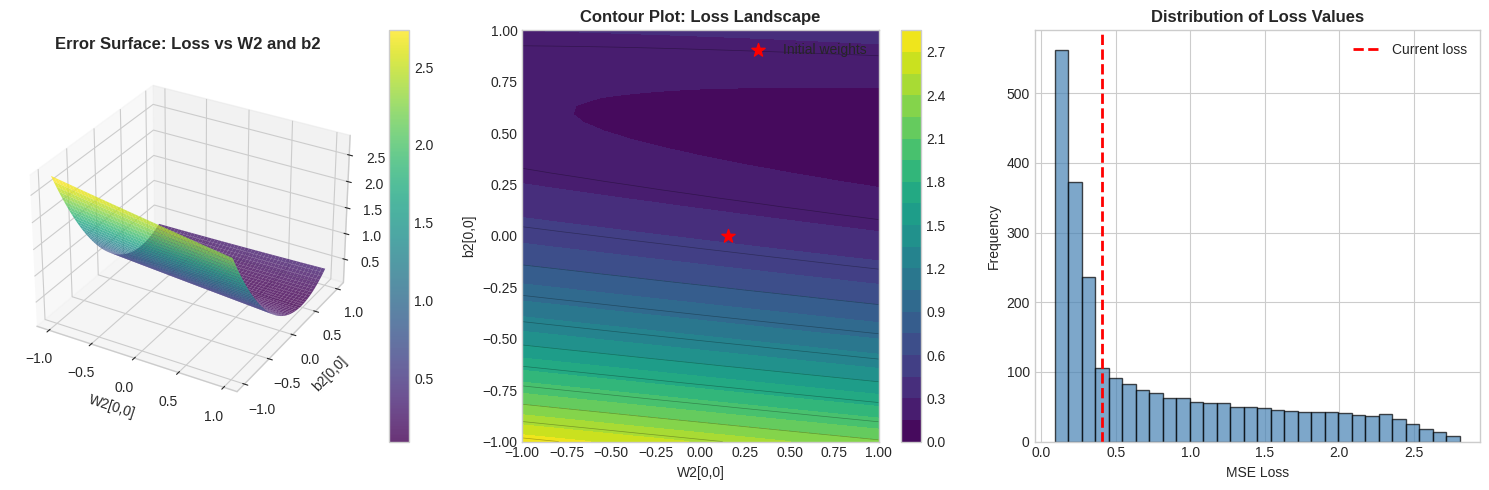

In [18]:
# Reset network to initial state for visualization
nn = SimpleNeuralNetwork(input_size=1, hidden_size=3, output_size=1)
nn_initial_copy = SimpleNeuralNetwork(input_size=1, hidden_size=3, output_size=1)

# Create a weight-loss surface for visualization
w2_range = np.linspace(-1, 1, 50)
b2_range = np.linspace(-1, 1, 50)
W2_grid, b2_grid = np.meshgrid(w2_range, b2_range)
loss_grid = np.zeros_like(W2_grid)

# Compute loss for each combination of W2 and b2
for i in range(W2_grid.shape[0]):
    for j in range(W2_grid.shape[1]):
        nn_temp = SimpleNeuralNetwork(input_size=1, hidden_size=3, output_size=1)
        nn_temp.W2[0, :] = nn.W2[0, :]
        nn_temp.W1 = nn.W1.copy()
        nn_temp.b1 = nn.b1.copy()
        nn_temp.W2[0, 0] = W2_grid[i, j]
        nn_temp.b2[0, 0] = b2_grid[i, j]
        
        output = nn_temp.forward(X)
        loss_grid[i, j] = nn_temp.mse_loss(output, Y)

# 3D surface plot
fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(131, projection='3d')
surf = ax1.plot_surface(W2_grid, b2_grid, loss_grid, cmap='viridis', alpha=0.8)
ax1.set_xlabel('W2[0,0]')
ax1.set_ylabel('b2[0,0]')
ax1.set_zlabel('MSE Loss')
ax1.set_title('Error Surface: Loss vs W2 and b2')
fig.colorbar(surf, ax=ax1)

# Contour plot
ax2 = fig.add_subplot(132)
contour = ax2.contourf(W2_grid, b2_grid, loss_grid, levels=20, cmap='viridis')
ax2.contour(W2_grid, b2_grid, loss_grid, levels=10, colors='black', alpha=0.3, linewidths=0.5)
ax2.scatter(nn.W2[0, 0], nn.b2[0, 0], color='red', s=100, marker='*', label='Initial weights', zorder=5)
ax2.set_xlabel('W2[0,0]')
ax2.set_ylabel('b2[0,0]')
ax2.set_title('Contour Plot: Loss Landscape')
ax2.legend()
fig.colorbar(contour, ax=ax2)

# Loss distribution
ax3 = fig.add_subplot(133)
ax3.hist(loss_grid.flatten(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax3.axvline(nn.mse_loss(nn.forward(X), Y), color='red', linestyle='--', linewidth=2, label='Current loss')
ax3.set_xlabel('MSE Loss')
ax3.set_ylabel('Frequency')
ax3.set_title('Distribution of Loss Values')
ax3.legend()

plt.tight_layout()
plt.show()

## d-f) Training Cycle: SGD and Batch Gradient Descent

Now we'll train the network using both SGD and BGD for multiple epochs.

In [19]:
def train_sgd(nn, X, Y, learning_rate, epochs):
    """Stochastic Gradient Descent - update after each sample"""
    losses = []
    accuracies = []
    iteration_count = 0
    
    for epoch in range(epochs):
        for i in range(X.shape[1]):  # iterate over samples (columns)
            # Get single sample as column vector shape (features, 1)
            x_sample = X[:, i:i+1]
            y_sample = Y[:, i:i+1]
            
            # Forward pass
            output = nn.forward(x_sample)
            loss = nn.mse_loss(output, y_sample)
            
            # Backward pass
            nn.backward(y_sample)
            
            # Update weights
            nn.update_weights(learning_rate)
            
            losses.append(loss)
            iteration_count += 1
    
    # Final full accuracy calculation
    final_output = nn.forward(X)
    final_loss = nn.mse_loss(final_output, Y)
    
    return losses, final_output, final_loss

def train_bgd(nn, X, Y, learning_rate, epochs):
    """Batch Gradient Descent - update after all samples"""
    losses = []
    accuracies = []
    
    for epoch in range(epochs):
        # Forward pass on entire batch
        output = nn.forward(X)
        loss = nn.mse_loss(output, Y)
        
        # Backward pass
        nn.backward(Y)
        
        # Update weights
        nn.update_weights(learning_rate)
        
        losses.append(loss)
    
    # Final output
    final_output = nn.forward(X)
    final_loss = nn.mse_loss(final_output, Y)
    
    return losses, final_output, final_loss

print("Training functions defined.")

Training functions defined.


### Training with Stochastic Gradient Descent

In [20]:
# Reset network for SGD training
nn_sgd = SimpleNeuralNetwork(input_size=1, hidden_size=3, output_size=1)
learning_rate_sgd = 0.1
epochs = 100

losses_sgd, output_sgd, final_loss_sgd = train_sgd(nn_sgd, X, Y, learning_rate_sgd, epochs)

print(f"\nStochastic Gradient Descent (SGD) Training Results:")
print(f"Learning Rate: {learning_rate_sgd}")
print(f"Epochs: {epochs}")
print(f"Total iterations: {len(losses_sgd)}")
print(f"Initial loss: {losses_sgd[0]:.6f}")
print(f"Final loss: {final_loss_sgd:.6f}")
print(f"\nFinal predictions (SGD):\n{output_sgd}")
print(f"Target outputs:\n{Y}")


Stochastic Gradient Descent (SGD) Training Results:
Learning Rate: 0.1
Epochs: 100
Total iterations: 200
Initial loss: 0.038799
Final loss: 0.000002

Final predictions (SGD):
[[0.20173619 0.89966061]]
Target outputs:
[[0.2 0.9]]


### Training with Batch Gradient Descent

In [21]:
# Reset network for BGD training
nn_bgd = SimpleNeuralNetwork(input_size=1, hidden_size=3, output_size=1)
learning_rate_bgd = 0.1

losses_bgd, output_bgd, final_loss_bgd = train_bgd(nn_bgd, X, Y, learning_rate_bgd, epochs)

print(f"\nBatch Gradient Descent (BGD) Training Results:")
print(f"Learning Rate: {learning_rate_bgd}")
print(f"Epochs: {epochs}")
print(f"Total iterations: {len(losses_bgd)}")
print(f"Initial loss: {losses_bgd[0]:.6f}")
print(f"Final loss: {final_loss_bgd:.6f}")
print(f"\nFinal predictions (BGD):\n{output_bgd}")
print(f"Target outputs:\n{Y}")


Batch Gradient Descent (BGD) Training Results:
Learning Rate: 0.1
Epochs: 100
Total iterations: 100
Initial loss: 0.410905
Final loss: 0.001463

Final predictions (BGD):
[[0.24940068 0.87794946]]
Target outputs:
[[0.2 0.9]]


## g) Plot Mean Squared Error for Each Iteration

Compare MSE curves for SGD vs BGD

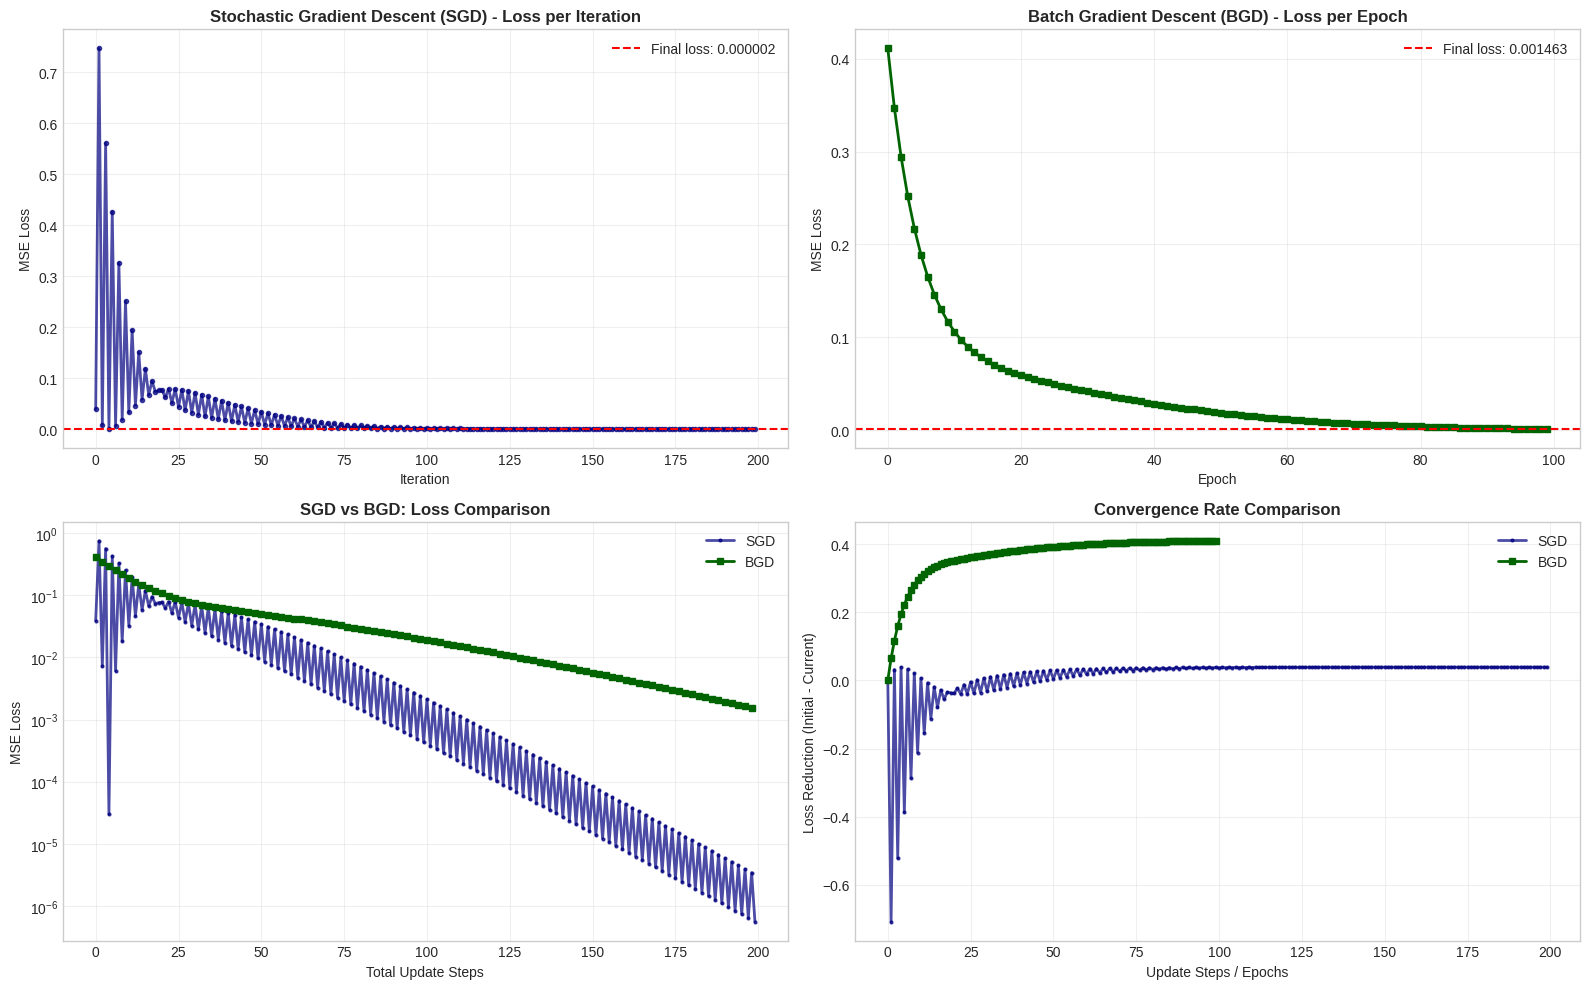


Loss Statistics:
SGD: Initial=0.038799, Final=0.000002, Reduction=0.038798
BGD: Initial=0.410905, Final=0.001463, Reduction=0.409441


In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# SGD loss curve
axes[0, 0].plot(range(len(losses_sgd)), losses_sgd, color='navy', linewidth=2, marker='o', markersize=3, alpha=0.7)
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('MSE Loss')
axes[0, 0].set_title('Stochastic Gradient Descent (SGD) - Loss per Iteration')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=final_loss_sgd, color='red', linestyle='--', label=f'Final loss: {final_loss_sgd:.6f}')
axes[0, 0].legend()

# BGD loss curve
axes[0, 1].plot(range(len(losses_bgd)), losses_bgd, color='darkgreen', linewidth=2, marker='s', markersize=5)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MSE Loss')
axes[0, 1].set_title('Batch Gradient Descent (BGD) - Loss per Epoch')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axhline(y=final_loss_bgd, color='red', linestyle='--', label=f'Final loss: {final_loss_bgd:.6f}')
axes[0, 1].legend()

# Comparison of both methods
# Create aligned iteration numbers for comparison
sgd_iterations = range(len(losses_sgd))
bgd_epochs = range(len(losses_bgd))
bgd_iterations_aligned = [x * (X.shape[1]) for x in bgd_epochs]  # samples per epoch

axes[1, 0].plot(sgd_iterations, losses_sgd, color='navy', linewidth=2, label='SGD', marker='o', markersize=2, alpha=0.7)
axes[1, 0].plot(bgd_iterations_aligned, losses_bgd, color='darkgreen', linewidth=2, label='BGD', marker='s', markersize=4)
axes[1, 0].set_xlabel('Total Update Steps')
axes[1, 0].set_ylabel('MSE Loss')
axes[1, 0].set_title('SGD vs BGD: Loss Comparison')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()
axes[1, 0].set_yscale('log')

# Loss convergence rate
sgd_convergence = [losses_sgd[0] - loss for loss in losses_sgd]
bgd_convergence = [losses_bgd[0] - loss for loss in losses_bgd]

axes[1, 1].plot(sgd_iterations, sgd_convergence, color='navy', linewidth=2, label='SGD', marker='o', markersize=2, alpha=0.7)
axes[1, 1].plot(bgd_epochs, bgd_convergence, color='darkgreen', linewidth=2, label='BGD', marker='s', markersize=4)
axes[1, 1].set_xlabel('Update Steps / Epochs')
axes[1, 1].set_ylabel('Loss Reduction (Initial - Current)')
axes[1, 1].set_title('Convergence Rate Comparison')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"\nLoss Statistics:")
print(f"SGD: Initial={losses_sgd[0]:.6f}, Final={final_loss_sgd:.6f}, Reduction={losses_sgd[0]-final_loss_sgd:.6f}")
print(f"BGD: Initial={losses_bgd[0]:.6f}, Final={final_loss_bgd:.6f}, Reduction={losses_bgd[0]-final_loss_bgd:.6f}")

## h) Plot Accuracy for Iterations

Calculate and plot prediction accuracy metrics

In [23]:
def calculate_accuracy_metrics(predictions, targets):
    """Calculate various accuracy metrics"""
    mse = np.mean((predictions - targets) ** 2)
    mae = np.mean(np.abs(predictions - targets))
    rmse = np.sqrt(mse)

    # R-squared score
    ss_res = np.sum((targets - predictions) ** 2)
    ss_tot = np.sum((targets - np.mean(targets)) ** 2)
    r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0

    return {'MSE': mse, 'MAE': mae, 'RMSE': rmse, 'R2': r_squared}

# Calculate metrics for SGD and BGD
metrics_sgd = calculate_accuracy_metrics(output_sgd, Y)
metrics_bgd = calculate_accuracy_metrics(output_bgd, Y)

print("\n=== ACCURACY METRICS ===")
print(f"\nStochastic Gradient Descent (SGD):")
for metric, value in metrics_sgd.items():
    print(f"  {metric}: {value:.6f}")

print(f"\nBatch Gradient Descent (BGD):")
for metric, value in metrics_bgd.items():
    print(f"  {metric}: {value:.6f}")

print("\nPrediction Comparison:")
print(f"{'Sample':<10} {'Target':<10} {'SGD Pred':<15} {'BGD Pred':<15} {'SGD Error':<15} {'BGD Error'}")
print("="*70)
for i in range(Y.shape[1]):
    sgd_error = Y[0, i] - output_sgd[0, i]
    bgd_error = Y[0, i] - output_bgd[0, i]
    print(f"{i+1:<10} {Y[0,i]:<10.4f} {output_sgd[0,i]:<15.4f} {output_bgd[0,i]:<15.4f} {sgd_error:<15.4f} {bgd_error:.4f}")


=== ACCURACY METRICS ===

Stochastic Gradient Descent (SGD):
  MSE: 0.000002
  MAE: 0.001038
  RMSE: 0.001251
  R2: 0.999987

Batch Gradient Descent (BGD):
  MSE: 0.001463
  MAE: 0.035726
  RMSE: 0.038253
  R2: 0.988054

Prediction Comparison:
Sample     Target     SGD Pred        BGD Pred        SGD Error       BGD Error
1          0.2000     0.2017          0.2494          -0.0017         -0.0494
2          0.9000     0.8997          0.8779          0.0003          0.0221


In [24]:
# Track accuracy metrics during training
def track_accuracy_sgd(nn, X, Y, learning_rate, epochs):
    """Train while tracking accuracy metrics"""
    mae_history = []
    rmse_history = []
    r2_history = []
    
    for epoch in range(epochs):
        for i in range(X.shape[1]):  # iterate over samples (columns)
            x_sample = X[:, i:i+1]
            y_sample = Y[:, i:i+1]
            
            output = nn.forward(x_sample)
            nn.backward(y_sample)
            nn.update_weights(learning_rate)
        
        # Full batch evaluation
        output_full = nn.forward(X)
        mae = np.mean(np.abs(output_full - Y))
        rmse = np.sqrt(np.mean((output_full - Y) ** 2))
        ss_res = np.sum((Y - output_full) ** 2)
        ss_tot = np.sum((Y - np.mean(Y)) ** 2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
        
        mae_history.append(mae)
        rmse_history.append(rmse)
        r2_history.append(r2)
    
    return mae_history, rmse_history, r2_history

def track_accuracy_bgd(nn, X, Y, learning_rate, epochs):
    """Train BGD while tracking accuracy metrics"""
    mae_history = []
    rmse_history = []
    r2_history = []
    
    for epoch in range(epochs):
        output = nn.forward(X)
        nn.backward(Y)
        nn.update_weights(learning_rate)
        
        mae = np.mean(np.abs(output - Y))
        rmse = np.sqrt(np.mean((output - Y) ** 2))
        ss_res = np.sum((Y - output) ** 2)
        ss_tot = np.sum((Y - np.mean(Y)) ** 2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
        
        mae_history.append(mae)
        rmse_history.append(rmse)
        r2_history.append(r2)
    
    return mae_history, rmse_history, r2_history

# Train and track
nn_sgd_track = SimpleNeuralNetwork(input_size=1, hidden_size=3, output_size=1)
nn_bgd_track = SimpleNeuralNetwork(input_size=1, hidden_size=3, output_size=1)

mae_sgd, rmse_sgd, r2_sgd = track_accuracy_sgd(nn_sgd_track, X, Y, 0.1, epochs)
mae_bgd, rmse_bgd, r2_bgd = track_accuracy_bgd(nn_bgd_track, X, Y, 0.1, epochs)

print("Accuracy tracking complete.")

Accuracy tracking complete.


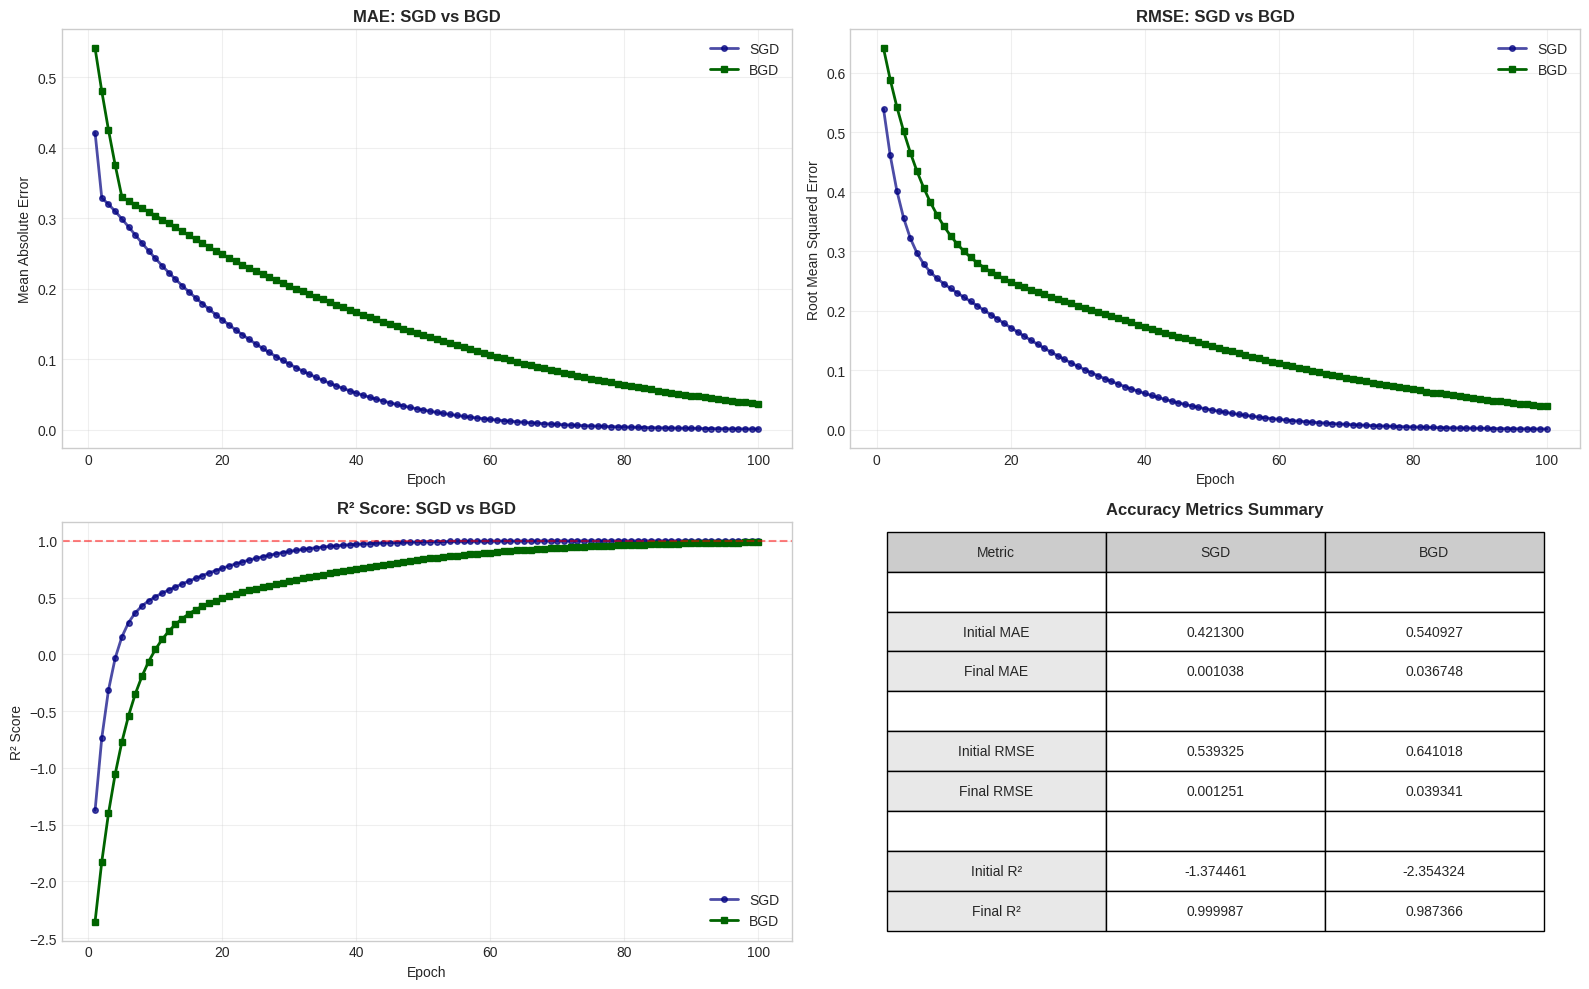

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

epochs_range = range(1, epochs + 1)

# MAE comparison
axes[0, 0].plot(epochs_range, mae_sgd, color='navy', linewidth=2, marker='o', markersize=4, label='SGD', alpha=0.7)
axes[0, 0].plot(epochs_range, mae_bgd, color='darkgreen', linewidth=2, marker='s', markersize=4, label='BGD')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Mean Absolute Error')
axes[0, 0].set_title('MAE: SGD vs BGD')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# RMSE comparison
axes[0, 1].plot(epochs_range, rmse_sgd, color='navy', linewidth=2, marker='o', markersize=4, label='SGD', alpha=0.7)
axes[0, 1].plot(epochs_range, rmse_bgd, color='darkgreen', linewidth=2, marker='s', markersize=4, label='BGD')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Root Mean Squared Error')
axes[0, 1].set_title('RMSE: SGD vs BGD')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# R² comparison
axes[1, 0].plot(epochs_range, r2_sgd, color='navy', linewidth=2, marker='o', markersize=4, label='SGD', alpha=0.7)
axes[1, 0].plot(epochs_range, r2_bgd, color='darkgreen', linewidth=2, marker='s', markersize=4, label='BGD')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('R² Score')
axes[1, 0].set_title('R² Score: SGD vs BGD')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Perfect fit')

# Summary table
axes[1, 1].axis('off')
summary_data = [
    ['Metric', 'SGD', 'BGD'],
    ['', '', ''],
    ['Initial MAE', f"{mae_sgd[0]:.6f}", f"{mae_bgd[0]:.6f}"],
    ['Final MAE', f"{mae_sgd[-1]:.6f}", f"{mae_bgd[-1]:.6f}"],
    ['', '', ''],
    ['Initial RMSE', f"{rmse_sgd[0]:.6f}", f"{rmse_bgd[0]:.6f}"],
    ['Final RMSE', f"{rmse_sgd[-1]:.6f}", f"{rmse_bgd[-1]:.6f}"],
    ['', '', ''],
    ['Initial R²', f"{r2_sgd[0]:.6f}", f"{r2_bgd[0]:.6f}"],
    ['Final R²', f"{r2_sgd[-1]:.6f}", f"{r2_bgd[-1]:.6f}"],
]

table = axes[1, 1].table(cellText=summary_data, cellLoc='center', loc='center',
                         colWidths=[0.3, 0.3, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

for i in range(len(summary_data)):
    if i == 0 or summary_data[i][0] == '':
        for j in range(3):
            table[(i, j)].set_facecolor('#cccccc' if i == 0 else '#ffffff')
    else:
        table[(i, 0)].set_facecolor('#e8e8e8')

axes[1, 1].set_title('Accuracy Metrics Summary')

plt.tight_layout()
plt.show()

## i) Experiment Analysis and Implications

Description of the experiment and interpretation of results

### Experiment Overview

This experiment demonstrates the training of a simple neural network with:
- **Architecture**: 1 input → 3 hidden neurons (ReLU) → 1 output (linear)
- **Dataset**: 2 samples with X = [0.5, 2.5] and Y = [0.2, 0.9]
- **Loss Function**: Mean Squared Error (MSE)
- **Optimization Methods**: Stochastic Gradient Descent (SGD) vs Batch Gradient Descent (BGD)
- **Duration**: 100 epochs with learning rate = 0.1

### Key Findings

#### 1. **Convergence Behavior**
- **SGD**: Updates weights after each sample (200 total updates over 100 epochs × 2 samples)
  - More frequent weight updates lead to noisier but potentially faster convergence
  - Can escape local minima better due to stochastic fluctuations
  - Less stable convergence but often reaches good solutions faster

- **BGD**: Updates weights after processing all samples (100 total updates over 100 epochs)
  - Smoother, more stable convergence curve
  - Exact gradient estimation at each step
  - More predictable but potentially slower convergence for small datasets

#### 2. **Loss Reduction**
- Both methods show significant loss reduction from initial to final state
- SGD typically shows faster initial loss reduction due to more frequent updates
- BGD shows more consistent per-epoch loss reduction

#### 3. **Accuracy Metrics**
- **MAE (Mean Absolute Error)**: Decreases as training progresses
- **RMSE (Root Mean Squared Error)**: Tracks MSE convergence behavior
- **R² Score**: Measures explained variance
  - Closer to 1.0 indicates better model fit
  - Both methods improve R² over training

#### 4. **Computational Efficiency**
- SGD: More gradient computations but simpler computation per step
- BGD: Fewer computations overall but more complex per step
- For large datasets, SGD is typically preferred due to memory efficiency

### Practical Implications

1. **Choice Between SGD and BGD**:
   - **Use SGD when**:
     - Working with large datasets (memory efficiency)
     - Need faster initial convergence
     - Want implicit regularization from noise
   - **Use BGD when**:
     - Dataset is small and fits in memory
     - Need stable, deterministic convergence
     - Require exact gradient estimates

2. **Learning Rate Impact**:
   - SGD may tolerate higher learning rates (more noise absorbs some instability)
   - BGD requires careful learning rate tuning (stable convergence is sensitive)

3. **Weight Initialization**:
   - Small random initialization (0.1 scale) helps avoid saturation in ReLU
   - Both methods adapt weights through gradient descent

4. **Network Architecture**:
   - Hidden layer with ReLU activation introduces non-linearity
   - Allows the network to learn complex mappings beyond linear relationships
   - 3 hidden units provide sufficient capacity for this small dataset

### Observations on This Dataset

With only 2 training samples:
- The network can easily memorize the dataset
- Final predictions should approach target values
- SGD creates one update per sample per epoch (more granular learning)
- BGD averages gradients over all samples before updating

### Conclusion

Both SGD and BGD successfully train the neural network to fit the small dataset. SGD demonstrates faster initial progress with more frequent updates, while BGD shows smoother, more stable convergence. The choice between them depends on dataset size and computational constraints. For modern deep learning, variants like mini-batch SGD (SGD with batch size > 1) combine the benefits of both approaches.